In [291]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

In [292]:
import eikon as ek
ek.set_app_key('9fbc5c01e4e34244bb166389f0515e16d536af6c')

2025-05-29 15:18:41,226 P[30332] [MainThread 4740] Error: no proxy address identified.
Check if Eikon Desktop or Eikon API Proxy is running.
2025-05-29 15:18:41,232 P[30332] [MainThread 4740] Error on handshake url http://127.0.0.1:None/api/handshake : InvalidURL("Invalid port: 'None'")
2025-05-29 15:18:41,235 P[30332] [MainThread 4740] Error on handshake url http://127.0.0.1:None/api/handshake : InvalidURL("Invalid port: 'None'")
2025-05-29 15:18:41,239 P[30332] [MainThread 4740] Port number was not identified, cannot send any request


In [175]:
from fredapi import Fred
fred = Fred(api_key='dfe993158907732d4528ece7f0693b3e')

## Helper Functions for Raw Data Processing

In [56]:
from statsmodels.tsa.stattools import adfuller

def ADF_test(time_series):

    '''
    Use adfuller(x, maxlag=None, regression='c', autolag
    ='AIC', store=False, regresults=False)

    Returns the following:
        - adf (float) – Test statistic
        - pvalue (float) – p-value    
    '''

    test_results = adfuller(time_series.dropna())
    test_statistic = test_results[0]
    p_value = test_results[1]

    #Critical Values
    Critical_Values = {}
    for threshold, adf_stat in test_results[4].items():
        Critical_Values[threshold] = adf_stat

    return test_statistic, p_value, Critical_Values['1%'], Critical_Values['5%'], Critical_Values['10%']


In [71]:
def split_into_dict(names : list,
                    df_raw_dict : dict):
    
    ''' 
    Takes many split csv files of different indicators/returns and combines it into one
    dictionary with keys for each indicator/returns.
    
    '''
    for i in names:
        try:
            df = pd.read_csv(r'Individual Datasets\{i}.csv', parse_dates=True)
        except :
            print(i)
            pass
        df.columns = ['Date', str(i)]
        df.set_index('Date', inplace=True)
        df_raw_dict[i] = df

    return df_raw_dict

In [58]:
def realign_indices(series_dict : dict, 
                   frequency : str,
                   template : str):    
    ''' 
    Realign indices from either daily/weekly to monthly => For indicator level data that we want transformed
    to monthly frequency. 

    Takes the mean

    '''
    df_template = series_dict[template]
    series_return = {}

    for i in series_dict:
        df = series_dict[i].copy()
        #If series is daily
        if series_dict[i].shape[0] > 2000:
            df.index = pd.to_datetime(df.index)
            df = df.resample(frequency).mean()
        #If weekly
        if series_dict[i].shape[0] < 2001 and series_dict[i].shape[0] > 800:
            df.index = pd.to_datetime(df.index)
            df = df.resample(frequency).mean()
            df.index = df.index.to_period(frequency).start_time
        #If monthly
        else:
            df.index = pd.to_datetime(df.index)

            if isinstance(df.index, pd.DatetimeIndex):
                pass
            else:
                df.index = df.index.to_timestamp(frequency)            
            
        df = series_dict[i].reindex(df_template.index)
        series_return[i] = df

    return series_return

In [59]:
def realign_indices_quarterly(series_dict : dict, 
                   frequency : str,
                   template : str):    
    ''' 
    Realign indices from monthly (or weekly/daily) to quarterly

    '''
    df_template = series_dict[template]
    series_return = {}

    for i in series_dict:
        df = series_dict[i].copy()
        #If series is daily
        if series_dict[i].shape[0] > 2000:
            df.index = pd.to_datetime(df.index)
            df = df.resample(frequency).mean()
        #If weekly
        if series_dict[i].shape[0] < 2001 and series_dict[i].shape[0] > 800:
            df.index = pd.to_datetime(df.index)
            df = df.resample(frequency).mean()
            df.index = df.index.to_period(frequency).start_time
        #If monthly
        else:
            df.index = pd.to_datetime(df.index)

            if isinstance(df.index, pd.DatetimeIndex):
                pass
            else:
                df.index = df.index.to_timestamp(frequency)            
            
        df = series_dict[i].reindex(df_template.index)
        series_return[i] = df

    return series_return


In [60]:
def find_ok_and_not_ok_series(rets : dict, 
                              raw_dict : dict, 
                              threshold : int = 50
                              ):
    ''' 
    Takes the raw dictionary so it can return the original series instead of the one altered
    by aligning function
    '''
    ok = {}
    not_ok = {}
    for i in rets:
        df_ = rets[i]
        if df_.iloc[:,0].isnull().sum() > threshold:
            not_ok[i] = raw_dict[i]
        else:
            ok[i] = df_

    return pd.concat(ok.values(), axis = 1), not_ok

In [61]:
def groupby_df(raw_df : pd.DataFrame,
               names : list):

    '''
    For processing raw dataframes that Refinitiv and other data sources create. Also returns dictionaries
    that contain the series that are incomplete or have null values.
    
    Takes a raw dataframe and groups it by the 'Instrument' column, which contains the names of the indicators.
    '''
    df_dict = {}
    incomplete = {}
    null_list = []
    good = {}
    

    for i in names:
        name = str(i)
        df = raw_df.groupby('Instrument').get_group(str(i)).copy()
        if df.shape[0] == 1:
            null_list.append(name)
            continue
        
        df.set_index('Date', inplace = True)
            
        df.index = pd.to_datetime(df.index).to_period('D')
        df.drop(columns = ['Instrument'], inplace = True)
        df.columns = [name]
        df_dict[name] = df

        null_count = df.isnull().sum().iloc[0]
        if null_count == 0:
            good[name] = df.iloc[:, 0]
            

        if null_count != 0:
            incomplete[name] = null_count

            if null_count < 10:
                good[name] = df.iloc[:,0]
    
    
    common_index = good[list(good.keys())[0]].index

    for i in good:
        good[i].drop_duplicates(inplace = True)
        good[i].dropna(inplace = True)
        good[i] = good[i].reindex(common_index)

    good = pd.concat(good, axis = 1)

    return good, null_list, incomplete

## Retrieving Indices, Indicators and Price Data 

https://www.usek.edu.lb/Content/Assets/20240205WorkspaceWAinstrumentCode.pdf

### US Sector Returns and Broad-Based Indices from Eikon

In [592]:
Indices_US_Canada = ['.DJI', '.IXIC', '.INX', '.NDX', 'OEX', '.SPX', '.SPSUPX','.GSPTSE']
Indices_Sector = ['.OEX','5SP10', '.5SP25', '.5SP40', '.5SP35', '.5SP55','.5SP60', '.5SP15', '.TRCCRBTR', '.MID', '.SPCY', '.SPCDNX']

In [ ]:
#5SP10 is empty and .SPCDNX
US_Sector_Indices.to_csv('Sector Returns 2005.csv')

#Returns with some duplicates
US_Indices, null_list_, empty_count = groupby_df(data, names = Indices_US_Canada)
US_Indices = Data_US_Canada.drop_duplicates()
US_Indices = Data_US_Canada.dropna()

#Save to CSV - GSPTSE not added yet
US_Indices.to_csv('US_Indices_2005_2025.csv')

#Must add GSPTSE 
GSPTSE = data.groupby('Instrument').get_group('.GSPTSE')
GSPTSE = GSPTSE.dropna().drop_duplicates()
GSPTSE = GSPTSE.set_index('Date')
GSPTSE.index = pd.to_datetime(GSPTSE.index).to_period('D')
GSPTSE = GSPTSE.reindex(Data_US_Canada.index)
GSPTSE = GSPTSE.drop(columns = ['Instrument'])
GSPTSE.columns = ['.GSPTSE']

#Refinitiv data has duplicates 
SPX = SPX[~SPX.index.duplicated(keep='first')]
SPX 

In [ ]:
# For loop to process raw data from refinitiv
SP_500_Sector_dfs = {}
for i in SP_indices:
    name = str(i) + '_df'
    df = SP_500_2005_2025.groupby('Instrument').get_group(str(i))
    df.set_index('Date', inplace = True)
    df.index = pd.to_datetime(df.index).to_period('D')
    SP_500_Sector_dfs[name] = df
    df.to_csv(f'SP500_Sector_{name}_2005_2025.csv')

In [239]:
NASDAQ_Names = ['MSFT.O','NVDA.O','AAPL.O','AMZN.O','GOOGL.O', 'META.O', 'TSLA.O', 'AVGO.O', 'BRKb.O', 'WMT.O', 'JPM.O', 'V.O', 'LLY.O', 'MA.O', 'NFLX.O', 'XOM.O', 'ORCL.O', 'COST.O', 'HD.O', 'PG.O', 'JNJ.O', 'BAC.O', 'ABBV.O', 'KO.O', 'UNH.O', 'CRM.O', 'TMUS.O', 'PM.O', 'WFC.O', 'CVX.O']
NYSE_Names = ['BRKb.N', 'WMT.N', 'JPM.N', 'V.N', 'LLY.N', 'MA.N', 'XOM.N', 'ORCL.N', 'HD.N', 'PG.N', 'JNJ.N', 'BAC.N', 'ABBV.N', 'KO.N', 'UNH.N', 'CRM.N', 'PM.N', 'WFC.N', 'CVX.N']

### Eurostoxx 60 Financial Sector Index

In [ ]:
Eurostoxx_RealEstate_Names = ['0#.SX86E']
Eurostoxx_Financial_Names = ['0#.SXFP']

Eurostoxx_R2, e = ek.get_data(Eurostoxx_RealEstate_Names,
                              fields = ['TR.Close', 'TR.ClosePrice.Date', 'TR.PriceClose', 'TR.PRICECLOSE'],
                              parameters = {'SDate': '2019-01-01',
                                    'EDate': '2025-05-27',
                                    'Frq':'D'})

Eurostoxx_Fin2, e = ek.get_data(Eurostoxx_Financial_Names,
                              fields = ['TR.Close', 'TR.ClosePrice.Date', 'TR.PriceClose', 'TR.PRICECLOSE'],
                              parameters = {'SDate': '2019-01-01',
                                    'EDate': '2025-05-27',
                                    'Frq':'D'})

Eurostoxx_RE_df, RE_null, RE_empty = groupby_df(Eurostoxx_R2, names = Eurostoxx_R2['Instrument'].unique().tolist())
Eurostoxx_Fin_df, Fin_null, FE_empty = groupby_df(Eurostoxx_Fin2, names = Eurostoxx_Fin2['Instrument'].unique().tolist())

### Processing Index Constitutents Data

In [14]:
Eurostoxx_Fin_Rawdf = pd.read_csv('Eurostoxx_Financial_Index_Members.csv')
Eurostoxx_RE_Rawdf = pd.read_csv('Real_Estate_Index.csv')
SP_Industrial_Rawdf = pd.read_csv('Industrial_Rets.csv')
NASDAQ_100_Rawdf = pd.read_csv('NASDAQ100_prices_index.csv')


C:\Users\Phillip\AppData\Local\Temp\ipykernel_27220\3588801005.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  SP_Industrial_Rawdf = pd.read_csv('Industrial_Rets.csv')
C:\Users\Phillip\AppData\Local\Temp\ipykernel_27220\3588801005.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  NASDAQ_100_Rawdf = pd.read_csv('NASDAQ100_prices_index.csv')


In [418]:
# Formatting Eurostoxx Financials
Eurostoxx_Fin_Rawdf2 = Eurostoxx_Fin_Rawdf.drop(
    columns = ['fic', 'isin', 'gvkey', 'prchd', 'prcld', 'cshtrd']).set_index(
        ['datadate', 'conm']).unstack(1).copy()

Eurostoxx_Fin_Rawdf2.index = pd.to_datetime(Eurostoxx_Fin_Rawdf2.index)
Eurostoxx_Fin_Rawdf3 = Eurostoxx_Fin_Rawdf2.loc['2019':].dropna(axis = 1).copy()
Eurostoxx_Fin_Rawdf3.index.name = 'Date'
Eurostoxx_Fin_Rawdf4 = Eurostoxx_Fin_Rawdf3['prccd'].copy()
Eurostoxx_Fin_Rawdf4 = (np.log(Eurostoxx_Fin_Rawdf4 / Eurostoxx_Fin_Rawdf4.shift()) * 100).dropna()
Eurostoxx_Fin_Rawdf4.columns.name = None
Eurostoxx_Fin_Rawdf4.to_csv('Eurostoxx_Financial_Sector_Prices.csv')


In [417]:
# Formatting Real Estate Financials
Eurostoxx_RE_Rawdf2 = Eurostoxx_RE_Rawdf.drop(
    columns = ['fic', 'isin', 'gvkey', 'prchd', 'prcld', 'cshtrd']).set_index(
        ['datadate', 'conm']).unstack(1).copy()

Eurostoxx_RE_Rawdf2.index = pd.to_datetime(Eurostoxx_RE_Rawdf2.index)
Eurostoxx_RE_Rawdf3 = Eurostoxx_RE_Rawdf2.loc['2019':].dropna(axis = 1).copy()
Eurostoxx_RE_Rawdf3.index.name = 'Date'
Eurostoxx_RE_Rawdf4 = Eurostoxx_RE_Rawdf3['prccd'].copy()
Eurostoxx_RE_Rawdf4 = (np.log(Eurostoxx_RE_Rawdf4 / Eurostoxx_RE_Rawdf4.shift()) * 100).dropna()
Eurostoxx_RE_Rawdf4.columns.name = None
Eurostoxx_RE_Rawdf4.to_csv('Eurostoxx_RealEstate_Sector_Prices.csv')

In [ ]:
SP_Industrial_Rawdf2 = SP_Industrial_Rawdf.drop(
    columns = ['gvkey', 'iid', 'prchd', 'prcld', 'prcod']).set_index(['datadate', 'tic']).unstack(1).copy()

SP_Industrial_Rawdf2.index = pd.to_datetime(SP_Industrial_Rawdf2.index)
SP_Industrial_Rawdf3 = SP_Industrial_Rawdf2['prccd'].copy()
SP_Industrial_Rawdf4 = SP_Industrial_Rawdf3.drop(['DAY.','BA.PA', 'ARNC.PB', 'HON.WI', 'DOV.WI', 'SWU', 'HUB.A', 'SWP.2', 'SWH', 'FTV.PA', 'SWT'], axis = 1)
SP_Industrial_Rawdf5 = SP_Industrial_Rawdf4.ffill(limit = 1)
SP_Industrial_Rawdf5 = (np.log(SP_Industrial_Rawdf5 / SP_Industrial_Rawdf5.shift()) * 100).dropna()
SP_Industrial_Rawdf5.index.name = 'Date'
SP_Industrial_Rawdf5.columns.name = None
SP_Industrial_Rawdf5.loc['2019':].to_csv('SP500_Industrials_Index_Returns.csv')

In [ ]:
# To filter out inactive NASDAQ members
NASDAQ_Tickers, e = ek.get_data(['0#.NDX'], fields = ['TR.ExchangeTicker'], parameters = {'SDate':'2025-01-01',
                                                                             'EDate': '2025-05-01'})

NASDAQ_Tickers = NASDAQ_Tickers['Exchange Ticker'].to_list()

NASDAQ_Active = []

for i in NASDAQ_Tickers:
    if i in NASDAQ_100_Rawdf4.columns:
        NASDAQ_Active.append(i)

In [92]:
NASDAQ_100_Rawdf2 = NASDAQ_100_Rawdf.drop(
    columns = ['gvkey', 'iid', 'prchd', 'prcld', 'prcod']).set_index(['datadate', 'tic']).unstack(1).copy()

NASDAQ_100_Rawdf2.index = pd.to_datetime(NASDAQ_100_Rawdf2.index)
NASDAQ_100_Rawdf3 = NASDAQ_100_Rawdf2['prccd'].copy()
NASDAQ_100_Rawdf3.index.name = 'Date'
NASDAQ_100_Rawdf4 = NASDAQ_100_Rawdf3.loc['2019':].copy().ffill(limit = 1).dropna(axis = 1)
NASDAQ_100_Rawdf4.columns.name = None
# GOOGL has 2 tickers, GOOG and GOOGL
NASDAQ_100_Rawdf5 = NASDAQ_100_Rawdf4[NASDAQ_Active].copy().drop(columns = ['GOOGL'])
NASDAQ_100_Rawdf5 = np.log( NASDAQ_100_Rawdf5 / NASDAQ_100_Rawdf5.shift()).dropna() * 100
NASDAQ_100_Rawdf5.to_csv('NASDAQ Index Returns.csv')

In [73]:
# Getting indice returns

index_list = ['.NDX', '.SPLRCI', '.SX86E', '.SXFE']

Eurostoxx_RE_Index_Price, e = ek.get_data('.SXFE', 
                               fields = ['TR.ClosePrice', 'TR.ClosePrice.Date'],
                               parameters = {'SDate': '2018-01-01',
                                             'EDate': '2025-05-20',
                                             'Frq': 'D'})

c:\Users\Phillip\AppData\Local\Programs\Python\Python39\lib\site-packages\eikon\data_grid.py:255: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [87]:
Eurostoxx_Financial_Index_Price2 = Eurostoxx_Financial_Index_Price.set_index('Date').drop(columns = ['Instrument'])
Eurostoxx_Financial_Index_Price2.index = pd.to_datetime(Eurostoxx_Financial_Index_Price2.index).strftime('%Y-%m-%d')
Eurostoxx_Financial_Index_Price2.columns.name = 'Eurostoxx Financial Index'
Eurostoxx_Financial_Index_Price2.to_csv('Eurostoxx_Financial_Index.csv')

In [85]:
Eurostoxx_RE_Index_Price2 = Eurostoxx_RE_Index_Price.set_index('Date').drop(columns = ['Instrument']).copy()
Eurostoxx_RE_Index_Price2.index = pd.to_datetime(Eurostoxx_RE_Index_Price2.index).strftime('%Y-%m-%d')
Eurostoxx_RE_Index_Price2.columns.name = 'Eurostoxx Real Estate Index'
Eurostoxx_RE_Index_Price2.to_csv('Eurostoxx_Real_Estate_Index.csv')

## Indicators and Economic Variables

Data below is retrieved from mainly Refinitiv. Some will be fed in as MIDAS variables as levels, some as first differences, some as log differences and quarterly annualised growth rates. An augmented Dickey Fuller test is applied to every indicator to ensure stationarity conditions.

## Processing and Compiling Indicator Data 

##### Pulling Data from FRED

In [560]:
Indicator_List_FRED = {
                'US EPU': 'USEPUINDXM',
                'China EPU': 'CHNMAINLANDEPU',
                'EU EPU': 'EUEPUINDXM',
                'Industrial Production (Manufacturing Only)': 'IPMAN',
                'Global Price of Industrial Materials': 'PINDUINDEXM',
                'Electricity Price CPI in US Cities': 'CUSR0000SEHF01',
                'Number of Car Sales': 'TOTALSA',
                'T10-2 yield curve (US)': 'T10Y2Y',
                'T10-3 yield curve (US)': 'T10Y3M',
                'Default Spread (BofA High Yield OAS)': 'BAMLH0A0HYM2',
                'Defaut Spread (BofA EU High Yield)': 'BAMLHE00EHYIOAS',
                    }

In [562]:
for key, value in Indicator_List_FRED.items():
    df = fred.get_series(value, observation_start = '2005-01-01')   
    df = pd.DataFrame(df)
    df.index = df.index.strftime('%Y-%m')
    df.columns = [key]
    df.to_csv(f'Individual Datasets\{key}.csv')

##### Citi Surprise Index

In [193]:
CitiSurpriseNames = ['.CESIEUR', '.CESICNY', '.CESIGL', '.CESIUSD', '.CESIG10']

CitiSurprise_raw_df, e = ek.get_data(['.CESIEUR', '.CESICNY', '.CESIGL', '.CESIUSD', '.CESIG10'],
                                     fields = ['TR.ClosePrice', 'TR.ClosePrice.Date'],
                                     parameters = {'SDate': '2005-01-01',
                                             'EDate': '2025-05-15',
                                             'Frq' : 'M'})

CitiSurprise_df = CitiSurprise_raw_df.copy()
CitiSurprise_df = CitiSurprise_df.reset_index().pivot(
    index = 'Date',
    columns = 'Instrument',
    values = 'Close Price'
)

CitiSurprise_df.index = pd.to_datetime(CitiSurprise_df.index).strftime('%Y-%m')
CitiSurprise_df.to_csv('Citi Surprise Indicators.csv')

Results = CitiSurprise_df.apply(lambda col : ADF_test(col)).round(2)
Results.index = ['T-stat', 'p-value', '1%', '5%', '10%']
Results.T

c:\Users\Phillip\AppData\Local\Programs\Python\Python39\lib\site-packages\eikon\data_grid.py:255: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


,T-stat,p-value,1%,5%,10%
Instrument,,,,,
.CESICNY,-2.84,0.05,-3.46,-2.87,-2.57
.CESIEUR,-4.03,0.00,-3.46,-2.87,-2.57
.CESIG10,-4.08,0.00,-3.46,-2.87,-2.57
.CESIGL,-4.12,0.00,-3.46,-2.87,-2.57
.CESIUSD,-4.23,0.00,-3.46,-2.87,-2.57


##### Yield Curve + Spreads

In [246]:
Euro_Yields = ['DE10YT=RR', 'DE2YT=RR', 'DE3MT=RR']

Euro_Yields_df, e = ek.get_data(Euro_Yields,
                                fields = ['TR.MidYield', 'TR.MidYield.Date'],
                                parameters = {'SDate': '2017-01-01',
                                             'EDate': '2025-05-15',
                                             'Frq' : 'D'})


c:\Users\Phillip\AppData\Local\Programs\Python\Python39\lib\site-packages\eikon\data_grid.py:255: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [ ]:
Euro_Yields_df1 = Euro_Yields_df.copy().drop_duplicates()
Euro_Yields_df1 = Euro_Yields_df1.reset_index().pivot(
    index = 'Date',
    columns = 'Instrument',
    values = 'Mid Yield'
)

Euro_Yields_df1.index = pd.to_datetime(Euro_Yields_df1.index)

Euro_Yields_df2 = Euro_Yields_df1.resample('ME').mean().copy()
Euro_Yields_df2.index = pd.to_datetime(Euro_Yields_df2.index).strftime('%Y-%m')
Euro_Yields_df2.rename(columns = {'DE10YT=RR': '10Y', 'DE2YT=RR': '2Y', 'DE3MT=RR': '3M'}, inplace = True)
Euro_Yields_df2.to_csv('Euro Yield Curve Data.csv')

Euro_10Y2Y = Euro_Yields_df2['10Y'] - Euro_Yields_df2['2Y']
Euro_10Y3M = Euro_Yields_df2['10Y'] - Euro_Yields_df2['3M']

Euro_Spreads = pd.concat([Euro_10Y2Y, Euro_10Y3M], axis = 1)
Euro_Spreads.columns = ['10Y2Y', '10Y3M']
Euro_Spreads.to_csv('Euro Spreads.csv')

# Must Difference 
Euro_Spreads = pd.concat([Euro_10Y2Y, Euro_10Y3M], axis = 1)
Euro_Spreads.columns = ['10Y2Y', '10Y3M']
Euro_Spreads.to_csv('Euro Spreads.csv')

# Check Stationarity
Results = Euro_Spreads.diff().apply(lambda col : ADF_test(col)).round(2)
Results.index = ['T-stat', 'p-value', '1%', '5%', '10%']
Results.T

,T-stat,p-value,1%,5%,10%
10Y2Y,-7.67,0.0,-3.5,-2.89,-2.58
10Y3M,-7.50,0.0,-3.5,-2.89,-2.58


##### Supply Chain + Industrial Indicators

In [66]:
GSCIP = pd.read_csv('.Global Supply Chain Index.csv', header = 0, index_col = [0], parse_dates = True)
GSCIP = GSCIP.iloc[:, 0]
GSCIP.index.name = 'Date'
GSCIP = pd.DataFrame(GSCIP)
GSCIP.columns = ['Global Supply Chain Pressure Index']

# Is stationary no need to transform it
Results = GSCIP.apply(lambda col : ADF_test(col)).round(2)
Results.index = ['T-stat', 'p-value', '1%', '5%', '10%']
GSCIP.loc['2005-01-01':].to_csv('Global Supply Chain Index.csv')
Results.T

,T-stat,p-value,1%,5%,10%
Global Supply Chain Pressure Index,-3.28,0.02,-3.46,-2.87,-2.57


##### Compiling Monthly Data

In [425]:
def combine_to_monthly(*series_list):

    cleaned = []

    for s in series_list:
        df = s.copy()
        
        # 1. Drop exact‐duplicate rows where both index and values match the previous row
        same_time = df.index.to_series().eq(df.index.to_series().shift())
        same_vals = df.eq(df.shift()).all(axis=1)
        mask = same_time & same_vals
        df = df.loc[~mask]

        # 2. Remove any remaining duplicate timestamps, keep first; sort
        df = df[~df.index.duplicated(keep="first")].sort_index()
        
        # 3. Ensure monthly frequency: infer, and if not month-end or month-start, resample
        freq = pd.infer_freq(df.index)
        if freq not in ("M", "MS", "BM", "BMS"):
            df = df.resample("ME").mean()
            df.index = df.index.to_period()
        else:
            df.index = df.index.to_period()
        cleaned.append(df)

    # 4. Inner-join on their common dates
    combined = pd.concat(cleaned, axis=1, join="outer")
    
    return combined

In [ ]:
def add_monthly_counter(df):
    
    df = df.copy()

    # 1) Parse index to datetime (handles '2005-03-1' vs '2005-03-01' for you)
    df.index = pd.to_datetime(df.index, infer_datetime_format=True)

    # 2) Group by year‐month, and count within each group
    #    cumcount() gives 0,1,2,... so add 1 to start at 1
    df['day_counter'] = (
        df
        .groupby(df.index.to_period('M'))
        .cumcount()
        .add(1)
    )
    month_ = df.index.to_period('M').to_timestamp()
    df.index = month_ + pd.to_timedelta(df['day_counter'].sub(1), unit = 'D')

    return df.drop(columns = ['day_counter'])



C:\Users\Phillip\AppData\Local\Temp\ipykernel_30332\1917393735.py:6: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df.index = pd.to_datetime(df.index, infer_datetime_format=True)


C:\Users\Phillip\AppData\Local\Temp\ipykernel_30332\1917393735.py:6: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df.index = pd.to_datetime(df.index, infer_datetime_format=True)
C:\Users\Phillip\AppData\Local\Temp\ipykernel_30332\1917393735.py:6: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df.index = pd.to_datetime(df.index, infer_datetime_format=True)
C:\Users\Phillip\AppData\Local\Temp\ipykernel_30332\1917393735.py:6: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now 

In [ ]:
# Volatility
skew = pd.read_csv(r'Individual Datasets\SkewX_2005_2025.csv', parse_dates = True, index_col = [0])
equity_vol_measure = pd.read_csv(r'Individual Datasets\Equity Vol Measure.csv', index_col = [0], parse_dates = True)
vix = pd.read_csv(r'Individual Datasets\VIX (good version).csv', parse_dates = True, index_col = [0]) 
MOVE = pd.read_csv(r'Individual Datasets\MOVE_2005_2025.csv', parse_dates = True, index_col=[0])
oil_vol = pd.read_csv(r'Individual Datasets\OVX_2007_2025.csv', parse_dates = True, index_col=[0])
VVIX = pd.read_csv(r'Individual Datasets\VVIX (good version).csv', parse_dates = True, index_col = [0])

# Sentiment
NFCI_Agg = pd.read_csv(r'Individual Datasets\NFCI.csv', parse_dates=True, index_col = [0])
UMich = pd.read_csv(r'Individual Datasets\UMich Sentiment.csv', parse_dates = True, index_col = [0]) 
BKK_NFCI_StLouis = pd.read_csv(r'Individual Datasets\BKK_NFCI_StLouis.csv', index_col = [0], parse_dates = True)
China_EPU = pd.read_csv(r'Individual Datasets\China EPU.csv', index_col = [0], parse_dates = True)
US_EPU = pd.read_csv(r'Individual Datasets\US EPU.csv', index_col = [0], parse_dates = True)
GPR_China_US_Saudi_Ger_Global = pd.read_csv(r'Individual Datasets\GPR (Differenced).csv', parse_dates = True, index_col = [0])
ESG = pd.read_csv(r'Individual Datasets\ESG.csv', index_col = [0], parse_dates = True)
Citi = pd.read_csv(r'Individual Datasets\Citi Surprise Indicators.csv', parse_dates = True, index_col = [0])

# Economic
Housing_Starts = pd.read_csv(r'Individual Datasets\Housing Start.csv', parse_dates = True, index_col=[0])
Unemployment_Rate = pd.read_csv(r'Individual Datasets\Unemployment Rate.csv', parse_dates = True, index_col=[0])
Inflation = pd.read_csv(r'Individual Datasets\Core Inflation.csv', parse_dates = True, index_col=[0])
CarSales = pd.read_csv(r'Individual Datasets\Number of Car Sales.csv', index_col = [0], parse_dates = True)
Electricity_Price = pd.read_csv(r'Individual Datasets\Electricity Price CPI in US Cities.csv', index_col = [0], parse_dates = True)

# Industrial
GSCIP = pd.read_csv(r'Individual Datasets\GSCIP.csv', index_col =[0], parse_dates = True)
IndPro = pd.read_csv(r'Individual Datasets\IndPro.csv', index_col =[0], parse_dates = True)
New_Orders = pd.read_csv(r'Individual Datasets\New Orders.csv', parse_dates = True, index_col=[0])
PPI = pd.read_csv(r'Individual Datasets\PPI.csv', parse_dates = True, index_col=[0])
IndPro_Manufacturing = pd.read_csv(r'Individual Datasets\Industrial Production (Manufacturing Only).csv', index_col = [0], parse_dates = True)
Industrial_Material_Prices = pd.read_csv(r'Individual Datasets\Global Price of Industrial Materials.csv', parse_dates = True, index_col = [0])

# Spreads
T10T2 = pd.read_csv(r'Individual Datasets\T10-2 yield curve (US).csv', index_col = [0], parse_dates = True)
T10M3 = pd.read_csv(r'Individual Datasets\T10-3 yield curve (US).csv', parse_dates = True, index_col = [0])
US_DefaultSpread = pd.read_csv(r'Individual Datasets\Default Spread (BofA High Yield OAS).csv', parse_dates = True, index_col = [0])
EU_DefaultSpread = pd.read_csv(r'Individual Datasets\Defaut Spread (BofA EU High Yield).csv', index_col = [0], parse_dates = True)
EU_YieldCurve = pd.read_csv(r'Individual Datasets\Euro Spreads.csv', index_col = [0], parse_dates = True)

In [ ]:
Spread_Indicators = combine_to_monthly(T10T2, T10M3, US_DefaultSpread, EU_DefaultSpread).loc['2008':'2025-03']
EU_DefaultSpread = add_monthly_counter(EU_DefaultSpread)
US_DefaultSpread = add_monthly_counter(US_DefaultSpread)
T10M3 = add_monthly_counter(T10M3)
T10T2 = add_monthly_counter(T10T2)
Spread_Indicators.to_csv('Spread Indicators.csv')

In [544]:
volatility_indicators = combine_to_monthly(skew, VVIX, vix, MOVE, oil_vol, equity_vol_measure)
volatility_indicators = volatility_indicators.loc['2008':'2025-03'].copy()
volatility_indicators.to_csv('Volatility Indicators.csv')

In [497]:
sentiment_indicators = combine_to_monthly(NFCI_Agg, UMich, BKK_NFCI_StLouis, China_EPU, US_EPU, GPR_China_US_Saudi_Ger_Global, ESG, Citi)
# Have to drop Citi Surprise Index for US and G10 -> but we have enough overlapping indices
sentiment_indicators = sentiment_indicators.loc['2008':'2025-03'].drop(columns = ['.CESIUSD', '.CESIG10']).copy()
sentiment_indicators.to_csv('Sentiment Indicators.csv')

In [531]:
Economic_Indicators = combine_to_monthly(Housing_Starts, Unemployment_Rate, Inflation, CarSales, Electricity_Price)
Economic_Indicators = Economic_Indicators.loc['2008':'2025-03-01'].copy()
Economic_Indicators.rename({'value':'Housing Starts', 'Electricity Price CPI in US Cities': 'US Electricity Price'}, inplace = True)
Economic_Indicators.to_csv('Economic Indicators.csv')


In [ ]:
# Industrial
Industrial_Indicators = combine_to_monthly(GSCIP, IndPro, New_Orders, PPI , IndPro_Manufacturing, Industrial_Material_Prices)
Industrial_Indicators.sort_index(inplace = True)
Industrial_Indicators = Industrial_Indicators.loc['2008':'2025-03-01'].copy()
Industrial_Indicators.to_csv('Industrial Indicators.csv')

In [ ]:
# Quarterly 


GDP = pd.read_csv(r'Individual Datasets\GDP.csv', parse_dates = True, index_col = [0])


### Returns of Indice Deep Dives

In [ ]:
# Returns of All Indices Constituents
SP_Industrial_df = pd.read_csv('SP500_Industrials_Index_Returns.csv', index_col = [0], parse_dates = True)
Eurostoxx_RE_df = pd.read_csv('Eurostoxx_RealEstate_Sector_Prices.csv',index_col = [0], parse_dates = True)
Eurostoxx_FinS_df = pd.read_csv('Eurostoxx_Financial_Sector_Prices.csv', index_col=[0], parse_dates=True)
NASDAQ_df = pd.read_csv('NASDAQ Index Returns.csv', parse_dates = True, index_col = [0])

In [686]:
# Returns of the Index
Financial_Index = pd.read_csv('Eurostoxx_Financial_Index.csv', index_col = [0], parse_dates = True)
RealEstate_Index = pd.read_csv('Eurostoxx_Real_Estate_Index.csv', index_col = [0], parse_dates = True)

Financial_Index = np.log(Financial_Index / Financial_Index.shift()).dropna() * 100
RealEstate_Index = np.log(RealEstate_Index / RealEstate_Index.shift()).dropna() * 100



#Fix NASDAQ and Industrials
NASDAQ_Industrials = pd.read_csv('nasdaq_us_industrial_index_rets.csv')
temp = NASDAQ_Industrials.drop(columns = ['gvkeyx']).pivot(
    index = 'datadate',
    values = 'prccd',
    columns = 'tic').copy()
NASDAQ = pd.DataFrame(temp['I0028'].copy())
SP_Industrials = pd.DataFrame(temp['IND.I'].copy())
NASDAQ.index.name = 'Date'
NASDAQ.columns = ['NASDAQ']
SP_Industrials.index.name = 'Date'
SP_Industrials.columns = ['SP Industrials']

NASDAQ = np.log(NASDAQ / NASDAQ.shift()).dropna() * 100
SP_Industrials = np.log(SP_Industrials/SP_Industrials.shift()).dropna() * 100

NASDAQ.to_csv('Returns - Index - NASDAQ.csv')
SP_Industrials.to_csv('Returns - Index - SP_Industrials.csv')
Financial_Index.to_csv('Returns - Index - Financials.csv')
RealEstate_Index.to_csv('Returns - Index - RealEstate.csv')


In [685]:
RealEstate_Index

,Close Price
Date,
2018-01-02,-0.323484
2018-01-03,0.636524
2018-01-04,2.148170
2018-01-05,0.735609
2018-01-08,0.703035
...,...
2025-05-14,0.396857
2025-05-15,-0.345177
2025-05-16,0.787795


### Fixing Indicator Level Data and Ensuring Alignment to Returns Data

In [224]:
# Some data needs manual processing (date formats don't line up etc...)
big_df = pd.read_csv('SP500_2005_2025.csv', parse_dates = True)
skew = pd.read_csv('SkewX_2005_2025.csv', parse_dates = True).dropna()
rvol = pd.read_csv('RVol_2005_2025.csv', parse_dates=True).dropna()
vix = pd.read_csv('VIX_2005_2025.csv', parse_dates = True)
vvix = pd.read_csv('VVIX_2006_2025.csv', parse_dates = True)
move = pd.read_csv('MOVE_2005_2025.csv', parse_dates=True)
citi = pd.read_csv('Citi Suprise Economic index 2005-2025.csv', parse_dates=True)
gold = pd.read_csv('GVZ_2008_2025.csv', parse_dates=True)
oil = pd.read_csv('OVX_2007_2025.csv', parse_dates=True)

abc = [big_df, skew, rvol, vix, vvix, move, citi, gold, oil]
#abc = [big_df, skew, rvol, vix, vvix, move, citi]

df_dict = {}
length = {}
for i in abc:
    df_copy = i.copy()
    df_copy.reset_index(inplace= True)
    df_copy = df_copy.drop_duplicates(subset=['Date']).set_index('Date')
    df_copy.index = pd.to_datetime(df_copy.index)
    df_copy = df_copy.loc['2006-03-01':'2025-05-05']
    name = df_copy['Instrument'].iloc[0].strip('.')
    df_copy.drop(columns = ['Instrument', 'index'], inplace = True)
    df_copy.columns = [name]
    df_dict[name] = df_copy
    length[name] = (df_copy.shape[0])

smallest_ = min(length, key = length.get)

for i in df_dict:
    if i != smallest_:
        df_mask = df_dict[i].index.difference(df_dict[smallest_].index)
        df = df_dict[i].drop(df_mask)
        df_dict[smallest_][i] = df
    else:
        pass

g = df_dict[smallest_].dropna().drop_duplicates(keep='first')


#Attaching GEP and GPR
GPR = pd.read_csv('Geopolitical Risk 1985-2025.csv', parse_dates=True).set_index('month')
GPR.index.name = 'Date'
GPR.index = pd.to_datetime(GPR.index)

GEP = pd.read_csv('Global Economic Policy Uncertainty Data.csv', parse_dates=True, index_col = 'Date')
GEP.columns = ['GEP']

#Assign to Main dataframe of SP
g['GPR'] = GPR['GPR'].reindex(g.index, method = 'ffill')
g['Year_Week'] = g.index.to_period('M').start_time
g['GEP'] = GEP['GEP'].reindex(g.index, method = 'ffill')
#Check
print(g.duplicated(keep=False).isnull().value_counts())

#Add Returns and Squared Returns
g['Returns'] = np.log(g['SPX'] / g['SPX'].shift(1)) * 100
g['Squared Returns'] = g.loc[:, 'Returns'] ** 2
g = g.dropna()
g.index.name = 'date'


False    4090
Name: count, dtype: int64


In [225]:
g

,GVZ,SPX,SKEWX,RVOL,VIX,VVIX,MOVE,CESIUSD,OVX,GPR,Year_Week,GEP,Returns,Squared Returns
date,,,,,,,,,,,,,,
2008-06-04,22.69,1377.20,114.37,13.42,20.80,81.04,131.90,-1.5,40.77,87.548424,2008-06-01,88.590383,-0.032670,0.001067
2008-06-05,22.78,1404.05,114.76,14.64,18.63,79.35,133.80,-0.9,41.37,87.548424,2008-06-01,88.590383,1.930847,3.728168
2008-06-06,23.60,1360.68,113.55,17.02,23.56,88.78,139.60,-5.3,52.03,87.548424,2008-06-01,88.590383,-3.137634,9.844749
2008-06-09,24.47,1361.76,114.98,16.98,23.12,92.23,151.00,-2.6,45.57,87.548424,2008-06-01,88.590383,0.079341,0.006295
2008-06-10,25.39,1358.44,114.30,16.86,23.18,91.98,149.60,-3.8,48.13,87.548424,2008-06-01,88.590383,-0.244100,0.059585
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-17,14.98,5996.66,165.35,17.18,15.97,101.61,95.60,22.8,33.52,112.377914,2025-01-01,365.025208,0.994143,0.988319
2025-01-21,15.50,6049.24,173.00,17.40,15.06,98.26,96.78,20.6,35.10,112.377914,2025-01-01,365.025208,0.873000,0.762128
2025-01-22,15.24,6086.37,179.98,13.97,15.10,100.56,89.90,19.8,34.68,112.377914,2025-01-01,365.025208,0.611920,0.374446


In [ ]:
names = ['BKK Leading Index',
       # 'Business Sentiment', Not needed and discontinued after 2024 as well
        'CFNAI',
        'Core Inflation',
        'Equity Vol Measure', # Equity Market Volatility : Macro News and Outlook (Business Sentiment)
        'GDP',
        'High Yield Spread',
        'Housing Start',
        'Industrial Production Index', #INDPRO (Seasonally adjusted)
        'LIBOR',
        'New Orders',
        'PPI', # All commodities PPIACO
        'STLSI',
        'T10Y2Y',
        'T10Y3M',
        'UMich Sentiment',
        'Unemployment Rate', #Seasonally adjusted
        'VIX',
        'VXN NASDAQ']

names_level = [ 'BKK Leading Index',
               # 'Business Sentiment',
                'CFNAI',
                'Equity Vol Measure',
                'High Yield Spread',
                'LIBOR',
                'STLSI',
                'VIX',
                'VXN NASDAQ']

names_pct_change = [#'Core Inflation',
                    'New Orders']

names_first_difference = ['Unemployment Rate', 
                          'UMich Sentiment', 
                          'T10Y3M',
                          'T10Y2Y']

names_quarterly_difference = ['GDP',
                            'Housing Start',
                            'Industrial Production Index',
                            'Core Inflation',
                            'PPI']

df_raw_dict = {}

In [69]:
df_levels = {}
df_pct_change = {}
df_first_difference = {}
df_quarterly = {}
df_raw = {}

In [72]:
df_levels = split_into_dict(names_level, df_levels)
df_pct_change = split_into_dict(names_pct_change, df_pct_change)
df_first_difference = split_into_dict(names_first_difference, df_first_difference)
df_quarterly = split_into_dict(names_quarterly_difference, df_quarterly)

BKK Leading Index


UnboundLocalError: local variable 'df' referenced before assignment

### Level Data

In [ ]:
#Re align indices to monthly
realigned_series_level = realign_indices(df_levels, 'M', 'BKK Leading Index')

#Check which ones worked 
good_df, need_manual = find_ok_and_not_ok_series(realigned_series_level, threshold = 50, raw_dict = df_levels)
print('Must manually fix :', need_manual.keys())

#Manually Combining : 'High Yield Spread', 'STLSI', 'T10Y2Y', 'T10Y3M', 'VIX', 'VXN NASDAQ'

VIX = df_levels['VIX']
VIX['VXN NASDAQ'] = df_levels['VXN NASDAQ']
VIX['High Yield Spread'] = df_levels['High Yield Spread']

#Adding in STLSI
STLSI = df_levels['STLSI'].copy()
STLSI.index = pd.to_datetime(STLSI.index)
STLSI = STLSI.resample('ME').mean()
STLSI.index = STLSI.index.to_period('M').start_time
good_df['St Louis Stress Index'] = STLSI

#Save to CSV
good_df.to_csv('Level_BKK_CFNAI_EquityVol_StLSI.csv')
VIX.to_csv('Level_VIX_TermSpread_2-10Spread_VXN.csv')

### First Difference

In [ ]:
#Step 1. Use Realign Function. Find the function with indices you want aligned to
first_diff_good_df, first_diff_need_manual = realign_indices(df_first_difference, 'M')

In [ ]:
UMich = df_first_difference['UMich Sentiment'].copy()
UMich['Unemployment Rate'] = df_first_difference['Unemployment Rate'].copy()
UMich['Recession Spread'] = df_first_difference['T10Y2Y'].copy()
UMich['Term Spread'] = df_first_difference['T10Y3M'].copy()
UMich = UMich.diff().loc['2005-01-01':].replace(np.nan, 0)

In [ ]:
#Save to CSV
UMich.to_csv('First_Diff_UMich_UnemploymentRate.csv')

### Quarterly Data : Annualised Growth Rate

Must manually sort :  GDP


C:\Users\Phillip\AppData\Local\Temp\ipykernel_20316\1493315444.py:9: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  df = df.resample('Q').sum()
C:\Users\Phillip\AppData\Local\Temp\ipykernel_20316\1493315444.py:11: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  df = df.resample('Q').mean()
C:\Users\Phillip\AppData\Local\Temp\ipykernel_20316\1493315444.py:11: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  df = df.resample('Q').mean()
C:\Users\Phillip\AppData\Local\Temp\ipykernel_20316\1493315444.py:11: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  df = df.resample('Q').mean()


<Axes: xlabel='Date'>

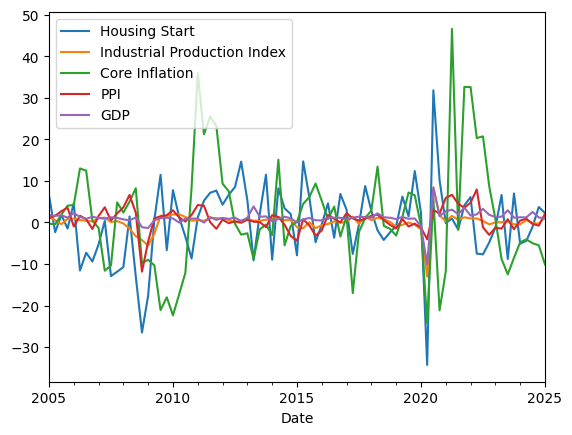

In [ ]:
quarterly_dict = {}
for i in df_quarterly:
    #Concat all the good series
    if df_quarterly[i].shape[0] > 200:
        df = df_quarterly[i].copy()
        df.index = df.index.astype(str)
        df.index = pd.to_datetime(df.index).to_period('M')
        if i == 'Housing Start':
            df = df.resample('Q').sum()
        else:
            df = df.resample('Q').mean()
        df.columns = [str(i)]
        quarterly_dict[i] = df
    else:
        print('Must manually sort : ', i)

#Combine into 1 Dataframe 
Quarterly_Diff = pd.concat(quarterly_dict, axis = 1)
Quarterly_Diff.columns = list(quarterly_dict.keys())
Quarterly_Diff = Quarterly_Diff.loc['2004Q2':] 

#Add GDP
GDP = df_quarterly['GDP'].copy()
GDP.index = pd.to_datetime(GDP.index).to_period('Q')
Quarterly_Diff['GDP'] = GDP

#Difference
Quarterly_Diff = 100*(Quarterly_Diff.diff() / Quarterly_Diff.rolling(4).mean())
Quarterly_Diff = Quarterly_Diff.dropna().round(3)

#PPI Not stationary - use log difference
Quarterly_Diff.plot()

In [ ]:
#Save to CSV
Quarterly_Diff.to_csv('Quarterly_Rate_Housing_IndProd_Inflation_PPI_GDP.csv')

### Compiling a Monthly Dataframe

In [ ]:
Level_df1 = pd.read_csv('Level_VIX_TermSpread_2-10Spread_VXN.csv', index_col = ['Date'], parse_dates=True)
Level_df2 = pd.read_csv('Level_BKK_CFNAI_EquityVol_StLSI.csv', index_col = ['Date'], parse_dates=True)
Quarterly_df = pd.read_csv('Quarterly_Rate_Housing_IndProd_Inflation_PPI_GDP.csv', index_col = ['Date'], parse_dates=True, date_format='%Y%Q')
First_Diff_df = pd.read_csv('First_Diff_UMich_UnemploymentRate.csv', index_col=['Date'], parse_dates=True)
MOVE_CESIUSD = pd.read_csv('MOVE_CESIUSD.csv', index_col=['Date'], parse_dates=True)
GPU = pd.read_csv('Geopolitical Risk 1985-2025.csv', index_col=['month'], parse_dates=True)
GEP = pd.read_csv('Global Economic Policy Uncertainty Data.csv', index_col = ['Date'], parse_dates = True)
NewOrders = pd.read_csv('New Orders.csv', index_col = [0], parse_dates=True)

In [ ]:
# GEP, GPU, New Orders
Risk = GPU['2004-12-01':].iloc[:,0]
Uncertainty = GEP['2004-12-01':].iloc[:,0]

#Add in New Orders, UMich, Term Spread and Unemployment Rate
Risk_Uncertainty_New_Orders = pd.concat([Risk, Uncertainty, NewOrders], axis = 1)
Risk_Uncertainty_New_Orders = (Risk_Uncertainty_New_Orders.diff() / Risk_Uncertainty_New_Orders) * 100
Risk_Uncertainty_New_Orders = pd.concat([Risk_Uncertainty_New_Orders, First_Diff_df], axis = 1)
Risk_Uncertainty_New_Orders = Risk_Uncertainty_New_Orders.dropna(how = 'all')
Risk_Uncertainty_New_Orders.to_csv('PercentDifferenced_Risk_Uncertainty_New_Orders_UMich_Unemployment.csv')

In [ ]:
# Combine CESIUSD and Move
Level_df1 = MOVE_CESIUSD.merge(Level_df1, how='outer', left_index=True, right_index=True).dropna(how = 'all')
Level_df1 = Level_df1.loc['2005':'2025-05-10'].copy()

# Get Level Data in Month Frequency
Level_df1_M = Level_df1.resample('M').last()

# Reindex to Monthly Frequency
Level_df1_M.index = Level_df1_M.index.to_period('M').start_time

#Combine DataFrames then save
Level_Monthly = pd.concat([Level_df1_M, Level_df2], axis=1)
Level_Monthly.to_csv('Level_Monthly.csv')

C:\Users\Phillip\AppData\Local\Temp\ipykernel_24520\679768490.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Level_df1_M = Level_df1.resample('M').last()


In [ ]:
''' 
Combining everything into MONTHLY Dataframe

'''

Level_Monthly = pd.read_csv('Level_Monthly.csv',index_col = [0], parse_dates=True)

Differenced_df = pd.read_csv('PercentDifferenced_Risk_Uncertainty_New_Orders_UMich_Unemployment.csv', index_col = [0], parse_dates=True)

Monthly = Differenced_df.merge(Level_Monthly, how = 'outer',
                               left_index = True, right_index = True
                               ).dropna(how='all'
                                        )

Monthly.replace(np.nan, 0, inplace = True)
Monthly.to_csv('Monthly Variables v1.csv')

In [ ]:
#Remove NAs from Monthly Economic Variables and Drop NAs
Monthly = Monthly.ffill().loc['2005-02':]

### Compiling Quarterly DataFrame - Finish

In [ ]:
# Specify which of the monthly variables we want to consider quarterly need to be summed instead of averaged / not applicable for quarters
Monthly = pd.read_csv('Monthly Variables v1.csv', index_col = [0], parse_dates = True)

Monthly.columns

Monthly_to_Drop = [' New Orders', 'VIX', 'VXN NASDAQ', 'High Yield Spread', 'Equity Vol Measure', 'Term Spread', 'Recession Spread', '.MOVE']

#Columns where the median makes more sense - spreads that measure underlying economic not market volatility 
Median = ['VIX', 'VXN NASDAQ', 'Term Spread']

#Columns where the highest value makes more sense - spreads that directly measure economic conditions - highest values within a quarter often 'remembered'
High = ['High Yield Spread', 'Equity Vol Measure', 'Recession Spread', '.MOVE']

#Columns where we need to sum
Sum = [' New Orders']

Monthly_to_Quarterly = list(set(Monthly.columns) - set(Monthly_to_Drop))

# Columns to Resample directly
Monthly_to_Q_df = Monthly[Monthly_to_Quarterly].copy()
Monthly_to_Q_df = Monthly_to_Q_df.resample('QE').mean()

#Different columns to median, high and sum
Monthly_to_Q_df[Median] = Monthly[Median].copy().resample('QE').median()
Monthly_to_Q_df[Sum] = Monthly[Sum].copy().resample('QE').sum()
Monthly_to_Q_df[High] = Monthly[High].copy().resample('QE').max()

Monthly_to_Q_df = Monthly_to_Q_df.round(3)

In [ ]:
#Merge into Quarterly Variables

Quarterly_df = pd.read_csv('Quarterly_Rate_Housing_IndProd_Inflation_PPI_GDP.csv', index_col = ['Date'])
Quarterly_df.index = pd.to_datetime(Quarterly_df.index).to_period('Q')
Monthly_to_Q_Merge = Monthly_to_Q_df.copy()
Monthly_to_Q_Merge.index = Monthly_to_Q_Merge.index.to_period('Q')
Quarterly = pd.concat([Quarterly_df, Monthly_to_Q_Merge], axis = 1)


C:\Users\Phillip\AppData\Local\Temp\ipykernel_24520\3173778257.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Quarterly_df.index = pd.to_datetime(Quarterly_df.index).to_period('Q')


In [ ]:
# Rename Columns
Quarterly.index = pd.PeriodIndex(Quarterly.index, freq='Q').to_timestamp()
Quarterly.index.name = 'Date'

#Save to CSV
Quarterly.to_csv('Quarterly.csv')

## Compiling and Processing of Broad-Indices and Sector-Indices Returns Data (Section X.X)

In [ ]:
US_indices = pd.read_csv('US_Indices_2005_2025.csv', index_col = [0], parse_dates = True)

#Creating DF with log returns and squared returns
US_indices_rets = np.log( US_indices / US_indices.shift()).dropna() * 100
US_indices_squared_rets = US_indices_rets ** 2
US_indices_returns_df = US_indices_rets.merge(right = US_indices_squared_rets, how = 'outer', suffixes=('', ' squared'), left_index=True, right_index=True)

#Creating Rolling Volatility (Realized)
''' to do '''

' to do '

In [ ]:
US_sectors = pd.read_csv('Sector_Indices_2005_2025.csv', index_col = [0], parse_dates = True)

#Creating DF with log returns and squared returns
US_sector_rets = np.log( US_sectors / US_sectors.shift()).dropna() * 100
US_sector_squared_rets = US_sector_rets ** 2
US_sector_rets_df = US_sector_rets.merge(right = US_sector_squared_rets, how = 'outer', suffixes=('', ' squared'), left_index=True, right_index=True)

#Creating Rolling Volatility (Realized)

In [ ]:
#Save to CSV
US_sector_rets_df.to_csv('Sector Returns.csv')
US_indices_returns_df.to_csv('Indices Returns.csv')

## Compiling and Processing of Index Constituent Data : S&P Industrials, Hang Seng Tech Index

## Unit Root / Stationarity Tests of Economic Variables

In [55]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
# Testing Monthly Data
Monthly = pd.read_csv('Monthly Variables v1.csv', parse_dates=True, index_col = [0])
Results = Monthly.apply(lambda col : ADF_test(col)).round(2)
Results.index = ['T-stat', 'p-value', '1%', '5%', '10%']
Results.T

,T-stat,p-value,1%,5%,10%
GPR,-7.78,0.00,-3.46,-2.87,-2.57
GEPU_current,-12.49,0.00,-3.46,-2.87,-2.57
New Orders,-15.08,0.00,-3.46,-2.87,-2.57
UMich Sentiment,-9.41,0.00,-3.46,-2.87,-2.57
Unemployment Rate,-12.26,0.00,-3.46,-2.87,-2.57
Recession Spread,-11.09,0.00,-3.46,-2.87,-2.57
Term Spread,-11.00,0.00,-3.46,-2.87,-2.57
.CESIUSD,-6.92,0.00,-3.46,-2.87,-2.57
.MOVE,-3.41,0.01,-3.46,-2.87,-2.57
VIX,-5.30,0.00,-3.46,-2.87,-2.57


In [ ]:
# Quarterly Tests
Quarterly = pd.read_csv('Quarterly.csv', index_col = [0], parse_dates=True, date_format = '%Y%QE')
Results = Quarterly.apply(lambda col : ADF_test(col)).round(2)
Results.index = ['T-stat', 'p-value', '1%', '5%', '10%']
Results.T

,T-stat,p-value,1%,5%,10%
Housing Start,-8.40,0.00,-3.51,-2.9,-2.59
Industrial Production Index,-8.58,0.00,-3.51,-2.9,-2.59
Core Inflation,-5.35,0.00,-3.52,-2.9,-2.59
PPI,-5.89,0.00,-3.52,-2.9,-2.59
GDP,-10.08,0.00,-3.51,-2.9,-2.59
UMich Sentiment,-12.24,0.00,-3.51,-2.9,-2.59
.CESIUSD,-7.42,0.00,-3.51,-2.9,-2.59
St Louis Stress Index,-3.40,0.01,-3.51,-2.9,-2.59
GEPU_current,-11.88,0.00,-3.51,-2.9,-2.59
GPR,-7.58,0.00,-3.52,-2.9,-2.59


In [ ]:
# Quarterly Tests 2 
Results = Monthly_to_Q_Merge.apply(lambda col : ADF_test(col)).round(2)
Results.index = ['T-stat', 'p-value', '1%', '5%', '10%']
Results.T

,T-stat,p-value,1%,5%,10%
UMich Sentiment,-12.24,0.00,-3.51,-2.9,-2.59
.CESIUSD,-7.42,0.00,-3.51,-2.9,-2.59
St Louis Stress Index,-3.40,0.01,-3.51,-2.9,-2.59
GEPU_current,-11.88,0.00,-3.51,-2.9,-2.59
GPR,-7.58,0.00,-3.52,-2.9,-2.59
BKK Leading Index,-3.50,0.01,-3.52,-2.9,-2.59
Unemployment Rate,-9.64,0.00,-3.51,-2.9,-2.59
CFNAI,-4.06,0.00,-3.51,-2.9,-2.59
VIX,-4.47,0.00,-3.51,-2.9,-2.59
VXN NASDAQ,-4.60,0.00,-3.51,-2.9,-2.59


## Unit Root Tests of Index Constitutents

### Testing S&P Industrials Members, Hang Seng TECH Index Members

In [15]:
industrial_df = pd.read_csv('SP_Industrial_index_constituent_returns_v3.csv', index_col = [0], parse_dates = True)
HangSeng_df = pd.read_csv('HK Sang Index Names.csv', index_col = [0], parse_dates = True)

C:\Users\Phillip\AppData\Local\Temp\ipykernel_31420\2951840185.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  HangSeng_df = pd.read_csv('HK Sang Index Names.csv', index_col = [0], parse_dates = True)


In [16]:
# Testing S&P Industrial Index Constituents 
Results_industrials = industrial_df.apply(lambda col : ADF_test(col)).round(2).T
Results_industrials.columns = ['T-stat', 'p-value', '1%', '5%', '10%']
(Results_industrials['p-value'] > 0.05).any()

np.False_